# 07 — Improvement Spiral on SwinIR


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import rasterio
from pathlib import Path
from scipy.ndimage import uniform_filter
from skimage.transform import resize as sk_resize
from tqdm import tqdm

sys.path.insert(0, "..")
from metrics import psnr, ssim, enl, evaluate_arrays, print_results

print(f"TensorFlow : {tf.__version__}")
print(f"GPUs       : {tf.config.list_physical_devices('GPU')}")

2026-04-12 16:25:22.184312: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776011122.421998      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776011122.490437      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776011123.002866      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776011123.002906      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776011123.002909      23 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
BASE_DIR = '/kaggle/input/datasets/vinhnh96/stac-dataset'

BASE_WORK_FROM_06 = '/kaggle/input/notebooks/vinhnh96/06-swinir'

BASE_WORK_DIR = '/kaggle/working'

DATASET_DIR  = Path(BASE_DIR + "/stac_dataset")

CKPT_BASE     = Path(BASE_WORK_FROM_06 + "/checkpoints")

CKPT_OUT = Path(BASE_WORK_DIR + "/checkpoints")

REPORTS_DIR  = Path(BASE_WORK_DIR + "/reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Native patch sizes on disk
NATIVE_LR = 128
NATIVE_HR = 512
SCALE     = 4

# Crop size fed to the model (same as 06_swinir for fair comparison)
LR_SIZE = 64
HR_SIZE = LR_SIZE * SCALE   # 256

# Lightweight SwinIR architecture (identical to 06_swinir)
EMBED_DIM   = 32
NUM_HEADS   = 4
WINDOW_SIZE = 8
STL_DEPTH   = 2
NUM_RSTB    = 2
MLP_RATIO   = 2.0

BATCH_SIZE = 16
EPOCHS     = 100
BASE_LR    = 2e-4
SEED       = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"LR_SIZE={LR_SIZE}, HR_SIZE={HR_SIZE}, SCALE={SCALE}")
print(f"EMBED_DIM={EMBED_DIM}, NUM_HEADS={NUM_HEADS}, WINDOW_SIZE={WINDOW_SIZE}")
print(f"STL_DEPTH={STL_DEPTH}, NUM_RSTB={NUM_RSTB}")

LR_SIZE=64, HR_SIZE=256, SCALE=4
EMBED_DIM=32, NUM_HEADS=4, WINDOW_SIZE=8
STL_DEPTH=2, NUM_RSTB=2


## SwinIR model classes

Copied verbatim from `06_swinir.ipynb` so results are directly comparable.

In [3]:
# ---------------------------------------------------------------------------
# Window utility functions
# ---------------------------------------------------------------------------

def window_partition(x, window_size):
    """Partition (B, H, W, C) into (num_windows*B, ws, ws, C)."""
    B = tf.shape(x)[0]
    H, W, C = x.shape[1], x.shape[2], x.shape[3]
    x = tf.reshape(x, [B, H // window_size, window_size,
                           W // window_size, window_size, C])
    x = tf.transpose(x, [0, 1, 3, 2, 4, 5])
    return tf.reshape(x, [-1, window_size, window_size, C])


def window_reverse(windows, window_size, H, W):
    """Reverse partition from (num_windows*B, ws, ws, C) back to (B, H, W, C)."""
    C = windows.shape[-1]
    num_win = (H // window_size) * (W // window_size)
    B = tf.shape(windows)[0] // num_win
    x = tf.reshape(windows, [B, H // window_size, W // window_size,
                                 window_size, window_size, C])
    x = tf.transpose(x, [0, 1, 3, 2, 4, 5])
    return tf.reshape(x, [B, H, W, C])


def compute_attn_mask(H, W, window_size, shift_size):
    """Precompute SW-MSA attention mask as a numpy-derived TF constant."""
    img_mask = np.zeros((1, H, W, 1), dtype=np.float32)
    h_slices = (slice(0, -window_size),
                slice(-window_size, -shift_size),
                slice(-shift_size, None))
    w_slices = (slice(0, -window_size),
                slice(-window_size, -shift_size),
                slice(-shift_size, None))
    cnt = 0
    for h in h_slices:
        for w in w_slices:
            img_mask[:, h, w, :] = cnt
            cnt += 1

    mask_win = window_partition(tf.constant(img_mask), window_size)
    mask_win = tf.reshape(mask_win, [-1, window_size * window_size])
    attn_mask = tf.expand_dims(mask_win, 1) - tf.expand_dims(mask_win, 2)
    attn_mask = tf.where(attn_mask != 0,
                         tf.fill(tf.shape(attn_mask), -100.0),
                         tf.zeros_like(attn_mask))
    return attn_mask

In [4]:
class RelativePositionBias(tf.keras.layers.Layer):
    """Trainable relative position bias added to attention logits."""

    def __init__(self, window_size, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.window_size = window_size
        self.num_heads = num_heads

        ws = window_size
        coords_h = np.arange(ws)
        coords_w = np.arange(ws)
        coords = np.stack(np.meshgrid(coords_h, coords_w, indexing="ij"))
        coords_flat = coords.reshape(2, -1)
        rel = coords_flat[:, :, None] - coords_flat[:, None, :]
        rel = rel.transpose(1, 2, 0)
        rel[:, :, 0] += ws - 1
        rel[:, :, 1] += ws - 1
        rel[:, :, 0] *= 2 * ws - 1
        self._rel_idx_np = rel.sum(-1).flatten().astype(np.int32)

    def build(self, input_shape=None):
        ws = self.window_size
        self.bias_table = self.add_weight(
            name="bias_table",
            shape=((2 * ws - 1) ** 2, self.num_heads),
            initializer="truncated_normal",
            trainable=True,
        )
        self.built = True

    def call(self, inputs=None):
        ws2 = self.window_size ** 2
        bias = tf.gather(self.bias_table, self._rel_idx_np)
        bias = tf.reshape(bias, [ws2, ws2, self.num_heads])
        bias = tf.transpose(bias, [2, 0, 1])
        return tf.expand_dims(bias, 0)


class WindowAttention(tf.keras.layers.Layer):
    def __init__(self, dim, window_size, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

    def build(self, input_shape=None):
        self.qkv  = tf.keras.layers.Dense(self.dim * 3, use_bias=True, name="qkv")
        self.proj = tf.keras.layers.Dense(self.dim, name="proj")
        self.rpb  = RelativePositionBias(self.window_size, self.num_heads, name="rpb")
        self.rpb.build(None)
        self.built = True

    def call(self, x, mask=None, training=None):
        B_ = tf.shape(x)[0]
        N  = self.window_size ** 2

        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, [B_, N, 3, self.num_heads, self.head_dim])
        qkv = tf.transpose(qkv, [2, 0, 3, 1, 4])
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = tf.matmul(q * self.scale, k, transpose_b=True)
        attn = attn + self.rpb()

        if mask is not None:
            nW = mask.shape[0]
            attn = tf.reshape(attn, [B_ // nW, nW, self.num_heads, N, N])
            attn = attn + tf.cast(
                tf.reshape(mask, [1, nW, 1, N, N]), tf.float32
            )
            attn = tf.reshape(attn, [B_, self.num_heads, N, N])

        attn = tf.nn.softmax(attn, axis=-1)

        out = tf.matmul(attn, v)
        out = tf.transpose(out, [0, 2, 1, 3])
        out = tf.reshape(out, [B_, N, self.dim])
        return self.proj(out)


class SwinTransformerBlock(tf.keras.layers.Layer):
    def __init__(self, dim, num_heads, window_size, shift_size,
                 mlp_ratio, input_resolution, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.shift_size = shift_size
        self.H, self.W = input_resolution
        self.window_size = window_size

        self._attn_mask = (
            compute_attn_mask(self.H, self.W, window_size, shift_size)
            if shift_size > 0 else None
        )

        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-5, name="norm1")
        self.attn  = WindowAttention(dim, window_size, num_heads, name="attn")
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-5, name="norm2")
        mlp_hidden = int(dim * mlp_ratio)
        self.mlp_fc1 = tf.keras.layers.Dense(mlp_hidden, activation="gelu", name="mlp1")
        self.mlp_fc2 = tf.keras.layers.Dense(dim, name="mlp2")

    def call(self, x, training=None):
        B  = tf.shape(x)[0]
        H, W, C = self.H, self.W, self.dim

        shortcut = x
        x = self.norm1(x)
        x = tf.reshape(x, [B, H, W, C])

        if self.shift_size > 0:
            x = tf.roll(x, shift=[-self.shift_size, -self.shift_size], axis=[1, 2])

        x_win = window_partition(x, self.window_size)
        x_win = tf.reshape(x_win, [-1, self.window_size ** 2, C])
        x_win = self.attn(x_win, mask=self._attn_mask, training=training)
        x_win = tf.reshape(x_win, [-1, self.window_size, self.window_size, C])
        x = window_reverse(x_win, self.window_size, H, W)

        if self.shift_size > 0:
            x = tf.roll(x, shift=[self.shift_size, self.shift_size], axis=[1, 2])

        x = tf.reshape(x, [B, H * W, C])
        x = shortcut + x
        x = x + self.mlp_fc2(self.mlp_fc1(self.norm2(x), training=training), training=training)
        return x


class RSTB(tf.keras.layers.Layer):
    """Residual Swin Transformer Block."""

    def __init__(self, dim, depth, num_heads, window_size,
                 mlp_ratio, input_resolution, **kwargs):
        super().__init__(**kwargs)
        self.H, self.W = input_resolution
        self.dim   = dim
        self._depth = depth

        for i in range(depth):
            setattr(self, f"stb_{i}", SwinTransformerBlock(
                dim=dim,
                num_heads=num_heads,
                window_size=window_size,
                shift_size=0 if (i % 2 == 0) else window_size // 2,
                mlp_ratio=mlp_ratio,
                input_resolution=input_resolution,
                name=f"stb_{i}",
            ))
        self.norm     = tf.keras.layers.LayerNormalization(epsilon=1e-5, name="norm")
        self.res_conv = tf.keras.layers.Conv2D(dim, 3, padding="same", name="res_conv")

    def call(self, x, training=None):
        B = tf.shape(x)[0]
        shortcut = x

        for i in range(self._depth):
            x = getattr(self, f"stb_{i}")(x, training=training)
        x = self.norm(x)

        x = tf.reshape(x, [B, self.H, self.W, self.dim])
        x = self.res_conv(x, training=training)
        x = tf.reshape(x, [B, self.H * self.W, self.dim])

        return shortcut + x


class SwinIR(tf.keras.Model):
    """Lightweight SwinIR (identical architecture to 06_swinir.ipynb)."""

    def __init__(self, lr_size, embed_dim, num_heads, window_size,
                 depth, num_rstb, mlp_ratio, upscale, **kwargs):
        super().__init__(name="SwinIR", **kwargs)
        self.lr_size   = lr_size
        self.embed_dim = embed_dim
        self.upscale   = upscale
        self._num_rstb = num_rstb
        res = (lr_size, lr_size)

        self.shallow_feat    = tf.keras.layers.Conv2D(embed_dim, 3, padding="same", name="shallow")
        for i in range(num_rstb):
            setattr(self, f"rstb_{i}",
                    RSTB(embed_dim, depth, num_heads, window_size, mlp_ratio, res, name=f"rstb_{i}"))
        self.norm            = tf.keras.layers.LayerNormalization(epsilon=1e-5, name="norm")
        self.conv_after_body = tf.keras.layers.Conv2D(embed_dim, 3, padding="same", name="conv_after_body")
        self.upsample_conv   = tf.keras.layers.Conv2D(embed_dim * upscale ** 2, 3, padding="same", name="upsample")
        self.conv_last       = tf.keras.layers.Conv2D(1, 3, padding="same", activation="sigmoid", name="conv_last")

    def call(self, x, training=None):
        B = tf.shape(x)[0]
        H = W = self.lr_size
        C = self.embed_dim

        feat = self.shallow_feat(x, training=training)
        seq  = tf.reshape(feat, [B, H * W, C])

        for i in range(self._num_rstb):
            seq = getattr(self, f"rstb_{i}")(seq, training=training)
        seq = self.norm(seq)

        deep = tf.reshape(seq, [B, H, W, C])
        deep = self.conv_after_body(deep, training=training)
        deep = deep + feat

        up = self.upsample_conv(deep, training=training)
        up = tf.nn.depth_to_space(up, self.upscale)
        return self.conv_last(up, training=training)


class SwinIRResidual(SwinIR):
    """SwinIR with pixel-level residual skip: output = sigmoid(sr_residual + bicubic_lr).

    The model learns to predict a residual correction on top of bicubic interpolation
    rather than the full SR image. This constrains the learning problem and
    typically accelerates convergence and improves structural fidelity.
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Override conv_last: linear activation (residual is added before sigmoid)
        self.conv_last = tf.keras.layers.Conv2D(
            1, 3, padding="same", activation=None, name="conv_last"
        )

    def call(self, x, training=None):
        B = tf.shape(x)[0]
        H = W = self.lr_size
        C = self.embed_dim

        feat = self.shallow_feat(x, training=training)
        seq  = tf.reshape(feat, [B, H * W, C])

        for i in range(self._num_rstb):
            seq = getattr(self, f"rstb_{i}")(seq, training=training)
        seq = self.norm(seq)

        deep = tf.reshape(seq, [B, H, W, C])
        deep = self.conv_after_body(deep, training=training)
        deep = deep + feat

        up = self.upsample_conv(deep, training=training)
        up = tf.nn.depth_to_space(up, self.upscale)
        sr_residual = self.conv_last(up, training=training)

        # Pixel-level skip: add bicubic upsampled input then clamp via sigmoid
        lr_up = tf.image.resize(x, [H * self.upscale, W * self.upscale], method="bicubic")
        return tf.sigmoid(sr_residual + lr_up)


def build_swinir(use_residual_skip=False):
    cls = SwinIRResidual if use_residual_skip else SwinIR
    model = cls(
        lr_size=LR_SIZE, embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
        window_size=WINDOW_SIZE, depth=STL_DEPTH, num_rstb=NUM_RSTB,
        mlp_ratio=MLP_RATIO, upscale=SCALE,
    )
    _ = model(tf.zeros([1, LR_SIZE, LR_SIZE, 1]), training=False)
    return model


print("SwinIR classes defined.")

SwinIR classes defined.


## Improvement helpers

In [5]:
# ---------------------------------------------------------------------------
# Improvement 1: Lee filter speckle pre-processing
# ---------------------------------------------------------------------------

def lee_filter(img, size=3):
    """Lee speckle reduction filter (numpy, operates on a 2-D float32 patch).

    Formula: output = mean + W * (x - mean)
    where W = sigma2_local / (sigma2_local + sigma2_noise)

    Reduces multiplicative SAR speckle while preserving edges better than
    a simple averaging filter.
    """
    img = img.astype(np.float32)
    img2 = img ** 2
    mean    = uniform_filter(img, size)
    sq_mean = uniform_filter(img2, size)
    var_local = sq_mean - mean ** 2
    var_noise = np.var(img) + 1e-8
    weight = var_local / (var_local + var_noise)
    return (mean + weight * (img - mean)).astype(np.float32)


# ---------------------------------------------------------------------------
# Improvement 2: Mixed L1 + SSIM loss
# ---------------------------------------------------------------------------

def l1_ssim_loss(alpha=0.84):
    """Return a combined L1 + (1 - SSIM) loss function.

    alpha=0.84 weights SSIM at 84% and L1 at 16%, following the recommendation
    in Zhao et al. (2017) 'Loss Functions for Image Restoration with Neural Networks'.
    SSIM loss captures perceptual quality (luminance, contrast, structure) that
    pure L1 misses, which is particularly important for speckled SAR textures.
    """
    def _loss(y_true, y_pred):
        l1 = tf.reduce_mean(tf.abs(y_true - y_pred))
        ssim_vals = tf.image.ssim(y_true, y_pred, max_val=1.0)
        ssim_loss = 1.0 - tf.reduce_mean(ssim_vals)
        return alpha * ssim_loss + (1.0 - alpha) * l1
    _loss.__name__ = f"l1_ssim_a{int(alpha * 100)}"
    return _loss


# ---------------------------------------------------------------------------
# Training helper
# ---------------------------------------------------------------------------

def train_variant(name, model, train_ds, val_ds, loss_fn, optimizer,
                  use_reduce_lr=True):
    """Train a model variant and return history. Saves best weights to CKPT_BASE/name/."""
    ckpt_dir = CKPT_OUT / name
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            str(ckpt_dir / "best.weights.h5"),
            save_weights_only=True,
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            verbose=1,
        ),
    ]
    if use_reduce_lr:
        callbacks.append(
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", factor=0.5, patience=5,
                min_lr=1e-6, verbose=1,
            )
        )

    model.compile(optimizer=optimizer, loss=loss_fn, metrics=["mse"])
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=2,
    )
    return history


# ---------------------------------------------------------------------------
# Test evaluation helper
# ---------------------------------------------------------------------------

def evaluate_on_test(model, test_idx_arr, hr_paths, lr_paths, use_lee=False):
    """Run the model on all test patches and return metric dict."""
    y_true_list, y_pred_list = [], []

    for idx in tqdm(test_idx_arr, desc="Evaluating"):
        with rasterio.open(hr_paths[idx]) as src:
            hr_full = src.read(1).astype(np.float32)
        with rasterio.open(lr_paths[idx]) as src:
            lr_full = src.read(1).astype(np.float32)

        max_val = hr_full.max()
        if max_val > 0:
            hr_full = hr_full / max_val
            lr_full = lr_full / max_val

        top  = (NATIVE_LR - LR_SIZE) // 2
        left = (NATIVE_LR - LR_SIZE) // 2
        lr_crop = np.clip(lr_full[top:top+LR_SIZE, left:left+LR_SIZE], 0, 1)
        hr_crop = hr_full[top*SCALE:(top+LR_SIZE)*SCALE, left*SCALE:(left+LR_SIZE)*SCALE]

        if use_lee:
            lr_crop = np.clip(lee_filter(lr_crop), 0.0, 1.0)

        lr_tensor = tf.constant(lr_crop[np.newaxis, ..., np.newaxis], dtype=tf.float32)
        sr_out = np.squeeze(model(lr_tensor, training=False).numpy())

        y_true_list.append(hr_crop)
        y_pred_list.append(sr_out)

    return evaluate_arrays(y_true_list, y_pred_list)


print("Helper functions defined.")

Helper functions defined.


## Dataset split and pipeline

In [6]:
all_hr = sorted(DATASET_DIR.glob("*_HR.tif"))
all_lr = sorted(DATASET_DIR.glob("*_LR.tif"))
assert len(all_hr) == len(all_lr), "HR/LR count mismatch"

n_total = len(all_hr)
indices = np.arange(n_total)
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

n_test  = int(n_total * 0.10)
n_val   = int(n_total * 0.10)
n_train = n_total - n_val - n_test

train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

print(f"Total  : {n_total:,}")
print(f"Train  : {len(train_idx):,}")
print(f"Val    : {len(val_idx):,}")
print(f"Test   : {len(test_idx):,}")

Total  : 6,047
Train  : 4,839
Val    : 604
Test   : 604


In [7]:
def make_dataset(idx_array, shuffle=False, train=False,
                 use_lee=False, use_augment=False):
    """Build a tf.data pipeline with optional Lee filtering and augmentation.

    Parameters
    ----------
    use_lee : bool
        Apply Lee speckle filter to LR patches before feeding to the model.
    use_augment : bool
        Apply random horizontal and vertical flips (training only).
    """
    hr_paths = [str(all_hr[i]) for i in idx_array]
    lr_paths = [str(all_lr[i]) for i in idx_array]

    def _load_and_normalise(hr_path, lr_path):
        with rasterio.open(hr_path) as src:
            hr = src.read(1).astype(np.float32)
        with rasterio.open(lr_path) as src:
            lr = src.read(1).astype(np.float32)
        max_val = hr.max()
        if max_val > 0:
            hr = hr / max_val
            lr = lr / max_val
        return hr, lr

    def load_train(hr_str, lr_str):
        hr, lr = _load_and_normalise(
            hr_str.numpy().decode(), lr_str.numpy().decode()
        )
        top  = np.random.randint(0, NATIVE_LR - LR_SIZE + 1)
        left = np.random.randint(0, NATIVE_LR - LR_SIZE + 1)
        lr_crop = np.clip(lr[top:top+LR_SIZE, left:left+LR_SIZE], 0, 1)
        hr_crop = hr[top*SCALE:(top+LR_SIZE)*SCALE, left*SCALE:(left+LR_SIZE)*SCALE]
        if use_lee:
            lr_crop = np.clip(lee_filter(lr_crop), 0.0, 1.0)
        return lr_crop[..., np.newaxis], hr_crop[..., np.newaxis]

    def load_eval(hr_str, lr_str):
        hr, lr = _load_and_normalise(
            hr_str.numpy().decode(), lr_str.numpy().decode()
        )
        top  = (NATIVE_LR - LR_SIZE) // 2
        left = (NATIVE_LR - LR_SIZE) // 2
        lr_crop = np.clip(lr[top:top+LR_SIZE, left:left+LR_SIZE], 0, 1)
        hr_crop = hr[top*SCALE:(top+LR_SIZE)*SCALE, left*SCALE:(left+LR_SIZE)*SCALE]
        if use_lee:
            lr_crop = np.clip(lee_filter(lr_crop), 0.0, 1.0)
        return lr_crop[..., np.newaxis], hr_crop[..., np.newaxis]

    load_fn = load_train if train else load_eval

    ds = tf.data.Dataset.from_tensor_slices((hr_paths, lr_paths))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(idx_array), seed=SEED)

    ds = ds.map(
        lambda hr, lr: tf.py_function(load_fn, [hr, lr], [tf.float32, tf.float32]),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    ds = ds.map(lambda lr, hr: (
        tf.ensure_shape(lr, [LR_SIZE, LR_SIZE, 1]),
        tf.ensure_shape(hr, [HR_SIZE, HR_SIZE, 1]),
    ))

    # Improvement 3: random flips applied after shape restoration
    if use_augment and train:
        def augment(lr, hr):
            seed_h = tf.random.uniform(shape=(), minval=0, maxval=2, dtype=tf.int32)
            seed_v = tf.random.uniform(shape=(), minval=0, maxval=2, dtype=tf.int32)
            lr = tf.cond(seed_h > 0, lambda: tf.image.flip_left_right(lr), lambda: lr)
            hr = tf.cond(seed_h > 0, lambda: tf.image.flip_left_right(hr), lambda: hr)
            lr = tf.cond(seed_v > 0, lambda: tf.image.flip_up_down(lr), lambda: lr)
            hr = tf.cond(seed_v > 0, lambda: tf.image.flip_up_down(hr), lambda: hr)
            return lr, hr
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


print("Dataset pipeline defined.")

Dataset pipeline defined.


## v0 — Baseline SwinIR

Load the best weights saved by `06_swinir.ipynb` and run evaluation on the same test set.
No retraining — results should match the Step 4 table exactly.

In [8]:
model_v0 = build_swinir(use_residual_skip=False)
v0_weights = CKPT_BASE / "swinir" / "best.weights.h5"
model_v0.load_weights(str(v0_weights))
print(f"Loaded weights from {v0_weights}")

results_v0 = evaluate_on_test(model_v0, test_idx, all_hr, all_lr, use_lee=False)
print_results(results_v0, "v0 — Baseline SwinIR (from 06_swinir checkpoint)")

I0000 00:00:1776011152.074572      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776011152.080550      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1776011155.867625      23 cuda_dnn.cc:529] Loaded cuDNN version 91002


Loaded weights from /kaggle/input/notebooks/vinhnh96/06-swinir/checkpoints/swinir/best.weights.h5


Evaluating: 100%|██████████| 604/604 [01:33<00:00,  6.45it/s]



v0 — Baseline SwinIR (from 06_swinir checkpoint)
------------------------------------
  PSNR      : 30.4033 dB
  SSIM      : 0.6652
  ENL pred  : 24.2797
  ENL true  : 10.5417
------------------------------------


## Improvement 1 — Lee Filter Speckle Pre-processing

In [9]:
CKPT_V1 = CKPT_BASE / "spiral_v1_lee"

train_ds_v1 = make_dataset(train_idx, shuffle=True,  train=True,  use_lee=True)
val_ds_v1   = make_dataset(val_idx,   shuffle=False, train=False, use_lee=True)

model_v1 = build_swinir(use_residual_skip=False)
optimizer_v1 = tf.keras.optimizers.Adam(learning_rate=BASE_LR)

history_v1 = train_variant(
    name="spiral_v1_lee",
    model=model_v1,
    train_ds=train_ds_v1,
    val_ds=val_ds_v1,
    loss_fn="mae",
    optimizer=optimizer_v1,
    use_reduce_lr=True,
)

results_v1 = evaluate_on_test(model_v1, test_idx, all_hr, all_lr, use_lee=True)
print_results(results_v1, "v1 — + Lee filter")

Epoch 1/100


I0000 00:00:1776011267.942088      70 service.cc:152] XLA service 0x7c9fc4002f00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776011267.942128      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776011267.942133      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2026-04-12 16:27:52.950763: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 16:27:53.090129: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1776011281.956289      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for th


Epoch 1: val_loss improved from inf to 0.03996, saving model to /kaggle/working/checkpoints/spiral_v1_lee/best.weights.h5
303/303 - 196s - 647ms/step - loss: 0.0496 - mse: 0.0061 - val_loss: 0.0400 - val_mse: 0.0038 - learning_rate: 2.0000e-04
Epoch 2/100

Epoch 2: val_loss improved from 0.03996 to 0.03900, saving model to /kaggle/working/checkpoints/spiral_v1_lee/best.weights.h5
303/303 - 59s - 193ms/step - loss: 0.0404 - mse: 0.0038 - val_loss: 0.0390 - val_mse: 0.0038 - learning_rate: 2.0000e-04
Epoch 3/100

Epoch 3: val_loss improved from 0.03900 to 0.03667, saving model to /kaggle/working/checkpoints/spiral_v1_lee/best.weights.h5
303/303 - 58s - 191ms/step - loss: 0.0388 - mse: 0.0036 - val_loss: 0.0367 - val_mse: 0.0033 - learning_rate: 2.0000e-04
Epoch 4/100

Epoch 4: val_loss improved from 0.03667 to 0.03560, saving model to /kaggle/working/checkpoints/spiral_v1_lee/best.weights.h5
303/303 - 59s - 195ms/step - loss: 0.0376 - mse: 0.0033 - val_loss: 0.0356 - val_mse: 0.0031 - l

Evaluating: 100%|██████████| 604/604 [01:03<00:00,  9.57it/s]



v1 — + Lee filter
------------------------------------
  PSNR      : 30.0291 dB
  SSIM      : 0.6295
  ENL pred  : 23.8081
  ENL true  : 10.5417
------------------------------------


## Improvement 2 — Mixed L1 + SSIM Loss

In [10]:
train_ds_v2 = make_dataset(train_idx, shuffle=True,  train=True,  use_lee=True)
val_ds_v2   = make_dataset(val_idx,   shuffle=False, train=False, use_lee=True)

model_v2 = build_swinir(use_residual_skip=False)
optimizer_v2 = tf.keras.optimizers.Adam(learning_rate=BASE_LR)

history_v2 = train_variant(
    name="spiral_v2_mixed_loss",
    model=model_v2,
    train_ds=train_ds_v2,
    val_ds=val_ds_v2,
    loss_fn=l1_ssim_loss(alpha=0.84),
    optimizer=optimizer_v2,
    use_reduce_lr=True,
)

results_v2 = evaluate_on_test(model_v2, test_idx, all_hr, all_lr, use_lee=True)
print_results(results_v2, "v2 — + Lee filter + Mixed L1/SSIM loss")

Epoch 1/100

Epoch 1: val_loss improved from inf to 0.43604, saving model to /kaggle/working/checkpoints/spiral_v2_mixed_loss/best.weights.h5
303/303 - 91s - 301ms/step - loss: 0.4814 - mse: 0.0102 - val_loss: 0.4360 - val_mse: 0.0042 - learning_rate: 2.0000e-04
Epoch 2/100

Epoch 2: val_loss improved from 0.43604 to 0.34359, saving model to /kaggle/working/checkpoints/spiral_v2_mixed_loss/best.weights.h5
303/303 - 59s - 193ms/step - loss: 0.4045 - mse: 0.0049 - val_loss: 0.3436 - val_mse: 0.0041 - learning_rate: 2.0000e-04
Epoch 3/100

Epoch 3: val_loss improved from 0.34359 to 0.31636, saving model to /kaggle/working/checkpoints/spiral_v2_mixed_loss/best.weights.h5
303/303 - 58s - 192ms/step - loss: 0.3279 - mse: 0.0039 - val_loss: 0.3164 - val_mse: 0.0035 - learning_rate: 2.0000e-04
Epoch 4/100

Epoch 4: val_loss improved from 0.31636 to 0.31131, saving model to /kaggle/working/checkpoints/spiral_v2_mixed_loss/best.weights.h5
303/303 - 58s - 193ms/step - loss: 0.3199 - mse: 0.0037 -

Evaluating: 100%|██████████| 604/604 [01:02<00:00,  9.64it/s]



v2 — + Lee filter + Mixed L1/SSIM loss
------------------------------------
  PSNR      : 29.6049 dB
  SSIM      : 0.6739
  ENL pred  : 11.2213
  ENL true  : 10.5417
------------------------------------


## Improvement 3 — Data Augmentation

In [11]:
train_ds_v3 = make_dataset(train_idx, shuffle=True,  train=True,  use_lee=True, use_augment=True)
val_ds_v3   = make_dataset(val_idx,   shuffle=False, train=False, use_lee=True)

model_v3 = build_swinir(use_residual_skip=False)
optimizer_v3 = tf.keras.optimizers.Adam(learning_rate=BASE_LR)

history_v3 = train_variant(
    name="spiral_v3_augment",
    model=model_v3,
    train_ds=train_ds_v3,
    val_ds=val_ds_v3,
    loss_fn=l1_ssim_loss(alpha=0.84),
    optimizer=optimizer_v3,
    use_reduce_lr=True,
)

results_v3 = evaluate_on_test(model_v3, test_idx, all_hr, all_lr, use_lee=True)
print_results(results_v3, "v3 — + Lee filter + Mixed loss + Augmentation")

Epoch 1/100

Epoch 1: val_loss improved from inf to 0.43325, saving model to /kaggle/working/checkpoints/spiral_v3_augment/best.weights.h5
303/303 - 90s - 298ms/step - loss: 0.4808 - mse: 0.0112 - val_loss: 0.4332 - val_mse: 0.0046 - learning_rate: 2.0000e-04
Epoch 2/100

Epoch 2: val_loss improved from 0.43325 to 0.31989, saving model to /kaggle/working/checkpoints/spiral_v3_augment/best.weights.h5
303/303 - 59s - 195ms/step - loss: 0.3770 - mse: 0.0048 - val_loss: 0.3199 - val_mse: 0.0034 - learning_rate: 2.0000e-04
Epoch 3/100

Epoch 3: val_loss improved from 0.31989 to 0.31174, saving model to /kaggle/working/checkpoints/spiral_v3_augment/best.weights.h5
303/303 - 59s - 194ms/step - loss: 0.3219 - mse: 0.0037 - val_loss: 0.3117 - val_mse: 0.0034 - learning_rate: 2.0000e-04
Epoch 4/100

Epoch 4: val_loss improved from 0.31174 to 0.31051, saving model to /kaggle/working/checkpoints/spiral_v3_augment/best.weights.h5
303/303 - 58s - 193ms/step - loss: 0.3169 - mse: 0.0035 - val_loss: 0

Evaluating: 100%|██████████| 604/604 [01:01<00:00,  9.79it/s]



v3 — + Lee filter + Mixed loss + Augmentation
------------------------------------
  PSNR      : 29.5900 dB
  SSIM      : 0.6756
  ENL pred  : 11.3827
  ENL true  : 10.5417
------------------------------------


## Improvement 4 — Cosine Decay Learning Rate Schedule

In [12]:
train_ds_v4 = make_dataset(train_idx, shuffle=True,  train=True,  use_lee=True, use_augment=True)
val_ds_v4   = make_dataset(val_idx,   shuffle=False, train=False, use_lee=True)

steps_per_epoch = len(train_idx) // BATCH_SIZE
cosine_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=BASE_LR,
    decay_steps=EPOCHS * steps_per_epoch,
    alpha=1e-5,
)

model_v4 = build_swinir(use_residual_skip=False)
optimizer_v4 = tf.keras.optimizers.Adam(learning_rate=cosine_schedule)

history_v4 = train_variant(
    name="spiral_v4_cosine_lr",
    model=model_v4,
    train_ds=train_ds_v4,
    val_ds=val_ds_v4,
    loss_fn=l1_ssim_loss(alpha=0.84),
    optimizer=optimizer_v4,
    use_reduce_lr=False,
)

results_v4 = evaluate_on_test(model_v4, test_idx, all_hr, all_lr, use_lee=True)
print_results(results_v4, "v4 — + Lee + Mixed loss + Augmentation + Cosine LR")

Epoch 1/100

Epoch 1: val_loss improved from inf to 0.43318, saving model to /kaggle/working/checkpoints/spiral_v4_cosine_lr/best.weights.h5
303/303 - 88s - 292ms/step - loss: 0.4815 - mse: 0.0099 - val_loss: 0.4332 - val_mse: 0.0041
Epoch 2/100

Epoch 2: val_loss improved from 0.43318 to 0.33244, saving model to /kaggle/working/checkpoints/spiral_v4_cosine_lr/best.weights.h5
303/303 - 58s - 191ms/step - loss: 0.3942 - mse: 0.0052 - val_loss: 0.3324 - val_mse: 0.0038
Epoch 3/100

Epoch 3: val_loss improved from 0.33244 to 0.31386, saving model to /kaggle/working/checkpoints/spiral_v4_cosine_lr/best.weights.h5
303/303 - 58s - 191ms/step - loss: 0.3273 - mse: 0.0040 - val_loss: 0.3139 - val_mse: 0.0035
Epoch 4/100

Epoch 4: val_loss improved from 0.31386 to 0.31243, saving model to /kaggle/working/checkpoints/spiral_v4_cosine_lr/best.weights.h5
303/303 - 58s - 192ms/step - loss: 0.3191 - mse: 0.0036 - val_loss: 0.3124 - val_mse: 0.0033
Epoch 5/100

Epoch 5: val_loss improved from 0.31243

Evaluating: 100%|██████████| 604/604 [01:02<00:00,  9.60it/s]



v4 — + Lee + Mixed loss + Augmentation + Cosine LR
------------------------------------
  PSNR      : 29.5598 dB
  SSIM      : 0.6731
  ENL pred  : 11.2195
  ENL true  : 10.5417
------------------------------------


## Training loss curves

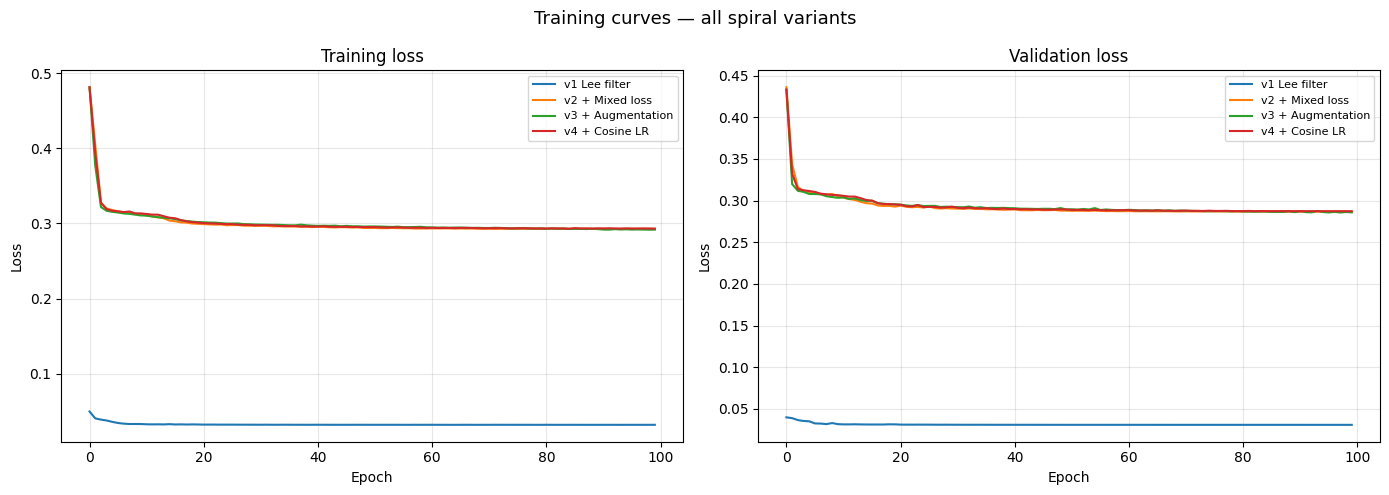

Saved: reports/fig_08_spiral_loss_curves.png


In [15]:
histories = [
    ("v1 Lee filter",          history_v1),
    ("v2 + Mixed loss",        history_v2),
    ("v3 + Augmentation",      history_v3),
    ("v4 + Cosine LR",         history_v4),
    # ("v5 + Residual skip",     history_v5),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training curves — all spiral variants", fontsize=13)

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

for ax, split_key, title in [
    (axes[0], "loss",     "Training loss"),
    (axes[1], "val_loss", "Validation loss"),
]:
    for (label, hist), color in zip(histories, colors):
        vals = hist.history.get(split_key, [])
        ax.plot(vals, label=label, color=color)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "fig_08_spiral_loss_curves.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved: reports/fig_08_spiral_loss_curves.png")

## Sample output grid — best variant vs baseline

Best variant by PSNR: v1 Lee (30.0291 dB)


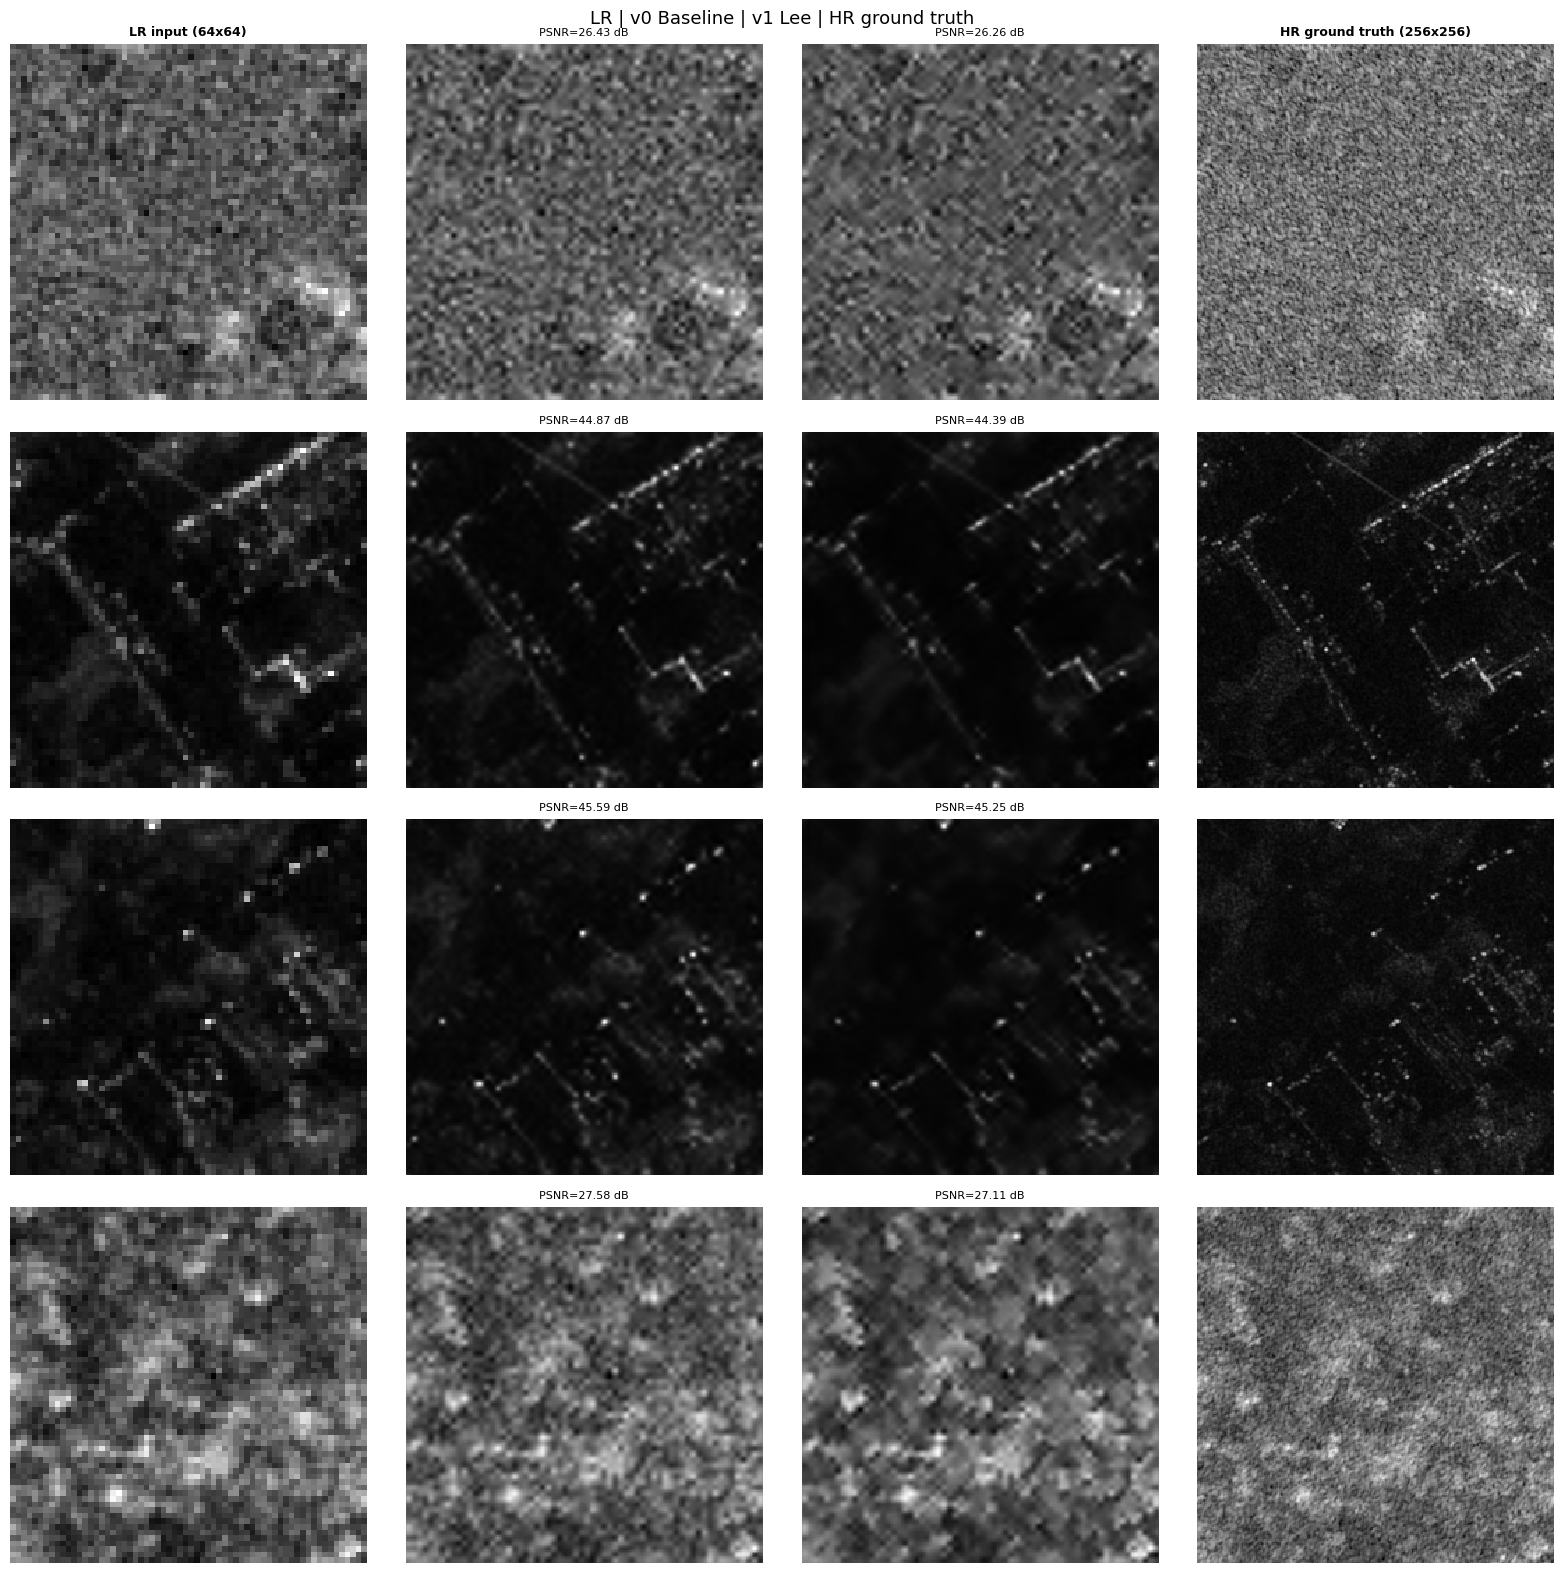

Saved: reports/fig_09_spiral_sample_outputs.png


In [ ]:
def log_display(arr):
    """Log-scale display for SAR amplitude (avoids bright-spot clipping)."""
    arr = np.clip(arr, 0.0, 1.0)
    return np.log1p(arr * 10) / np.log1p(10)


def center_crop_lr(lr_full, hr_full):
    top  = (NATIVE_LR - LR_SIZE) // 2
    left = (NATIVE_LR - LR_SIZE) // 2
    return (
        lr_full[top:top+LR_SIZE, left:left+LR_SIZE],
        hr_full[top*SCALE:(top+LR_SIZE)*SCALE, left*SCALE:(left+LR_SIZE)*SCALE],
    )


# Determine best variant by PSNR
spiral_results = [
    ("v1 Lee",                results_v1),
    ("v2 +MixedLoss",         results_v2),
    ("v3 +Augment",           results_v3),
    ("v4 +CosineLR",          results_v4),
]
spiral_models = [model_v1, model_v2, model_v3, model_v4]
spiral_lees   = [True, True, True, True]

best_idx = max(range(len(spiral_results)), key=lambda i: spiral_results[i][1]['psnr'])
best_label, best_results = spiral_results[best_idx]
best_model = spiral_models[best_idx]
best_use_lee = spiral_lees[best_idx]
print(f"Best variant by PSNR: {best_label} ({best_results['psnr']:.4f} dB)")

N_SHOW = 4
show_idx = np.random.default_rng(SEED).choice(len(test_idx), size=N_SHOW, replace=False)

fig, axes = plt.subplots(N_SHOW, 4, figsize=(16, N_SHOW * 4))
fig.suptitle(f"LR | v0 Baseline | {best_label} | HR ground truth", fontsize=13)

col_titles = [
    f"LR input ({LR_SIZE}x{LR_SIZE})",
    f"v0 Baseline ({HR_SIZE}x{HR_SIZE})",
    f"{best_label} ({HR_SIZE}x{HR_SIZE})",
    f"HR ground truth ({HR_SIZE}x{HR_SIZE})",
]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=9, fontweight="bold")

for row, si in enumerate(show_idx):
    orig_idx = test_idx[si]
    with rasterio.open(all_lr[orig_idx]) as src:
        lr_raw = src.read(1).astype(np.float32)
    with rasterio.open(all_hr[orig_idx]) as src:
        hr_raw = src.read(1).astype(np.float32)

    max_val = hr_raw.max()
    lr_norm = lr_raw / max_val if max_val > 0 else lr_raw
    hr_norm = hr_raw / max_val if max_val > 0 else hr_raw

    lr_crop, hr_crop = center_crop_lr(lr_norm, hr_norm)
    lr_crop = np.clip(lr_crop, 0.0, 1.0)

    # v0 output (no Lee)
    lr_t = tf.constant(lr_crop[np.newaxis, ..., np.newaxis], dtype=tf.float32)
    sr_v0  = np.squeeze(model_v0(lr_t, training=False).numpy())

    # Best variant output (with Lee filter if applicable)
    lr_best = np.clip(lee_filter(lr_crop), 0.0, 1.0) if best_use_lee else lr_crop
    lr_t2   = tf.constant(lr_best[np.newaxis, ..., np.newaxis], dtype=tf.float32)
    sr_best = np.squeeze(best_model(lr_t2, training=False).numpy())

    axes[row, 0].imshow(log_display(lr_crop), cmap="gray", interpolation="nearest")
    axes[row, 1].imshow(log_display(sr_v0),   cmap="gray", interpolation="nearest")
    axes[row, 2].imshow(log_display(sr_best),  cmap="gray", interpolation="nearest")
    axes[row, 3].imshow(log_display(hr_crop),  cmap="gray", interpolation="nearest")

    psnr_v0   = psnr(hr_crop, sr_v0)
    psnr_best = psnr(hr_crop, sr_best)
    axes[row, 1].set_title(f"PSNR={psnr_v0:.2f} dB", fontsize=8)
    axes[row, 2].set_title(f"PSNR={psnr_best:.2f} dB", fontsize=8)
    for col in range(4):
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "fig_09_spiral_sample_outputs.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved: reports/fig_09_spiral_sample_outputs.png")